# Bivariate Analysis

## Importing Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import sys
import os

sys.path.append(os.path.abspath(".."))

from src.utils import display_side_by_side


print("loaded")

loaded


## Importing Data

In [7]:
df = pd.read_csv("/Users/yushinnam/projects/health-insurance-claims/data/processed/insurance_data_cleaned.csv")

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop(['index', 'PatientID'])
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols_small = numerical_cols.copy().drop('claim')

df.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24,male,30.1,87,No,0,No,southeast,1131.51
2,7,8,19,male,41.1,100,No,0,No,northwest,1146.80
3,8,9,20,male,43.0,86,No,0,No,northwest,1149.40
4,9,10,30,male,53.1,97,No,0,No,northwest,1163.46


## Numerical Risk Factors

In [8]:
def scatter_with_avg(data, x_col, y_col, ax):
    ax.scatter(data[x_col], data[y_col], alpha=0.3)
    
    for val in data[x_col].unique():
        avg_y = data[data[x_col] == val][y_col].mean()
        ax.plot(val, avg_y, color='red', marker='o', markersize=4)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'Scatter Plot of {y_col} vs {x_col}')

def scatter_with_avg_log(data, x_col, y_col, ax):
    ax.scatter(data[x_col], np.log(data[y_col]), alpha=0.3)
    
    for val in data[x_col].unique():
        avg_y = np.log(data[data[x_col] == val][y_col].mean())
        ax.plot(val, avg_y, color='red', marker='o', markersize=4)

    ax.set_xlabel(x_col)
    ax.set_ylabel(f'Log of {y_col}')
    ax.set_title(f'Scatter Plot of Log({y_col}) vs {x_col}')

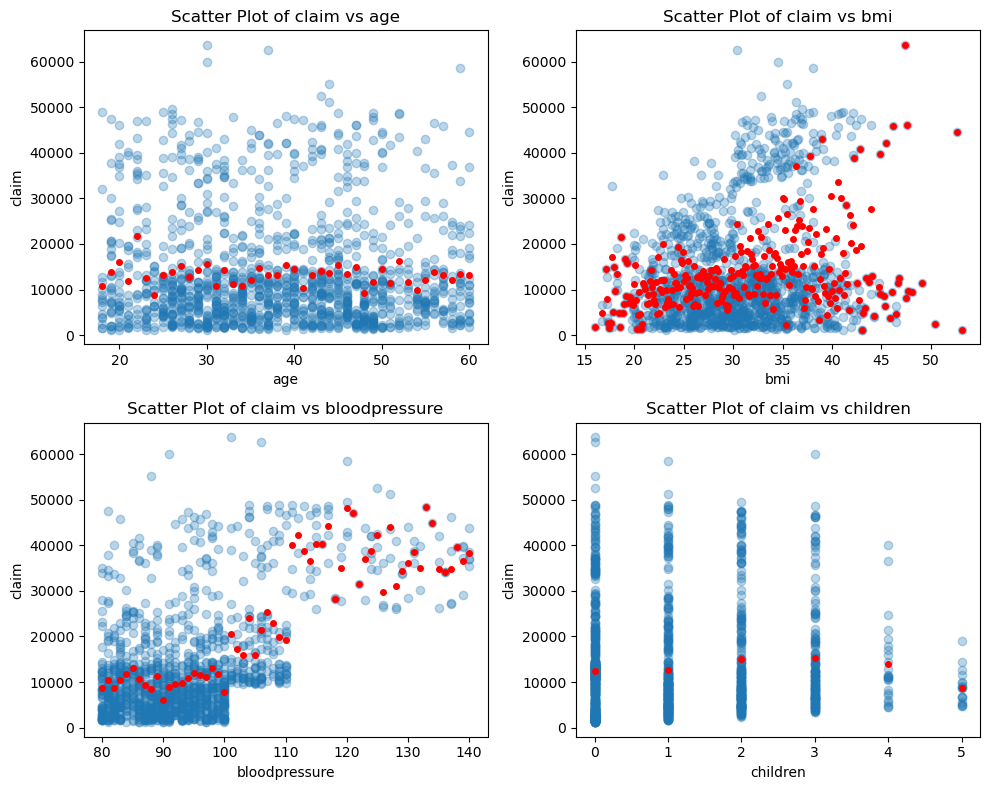

In [10]:
fig, axes = plt.subplots(2,2, figsize=(10,8))

axes = axes.flatten()

for i, col in enumerate(numerical_cols_small):
    scatter_with_avg(df, col, 'claim', axes[i])

plt.tight_layout()
plt.show()

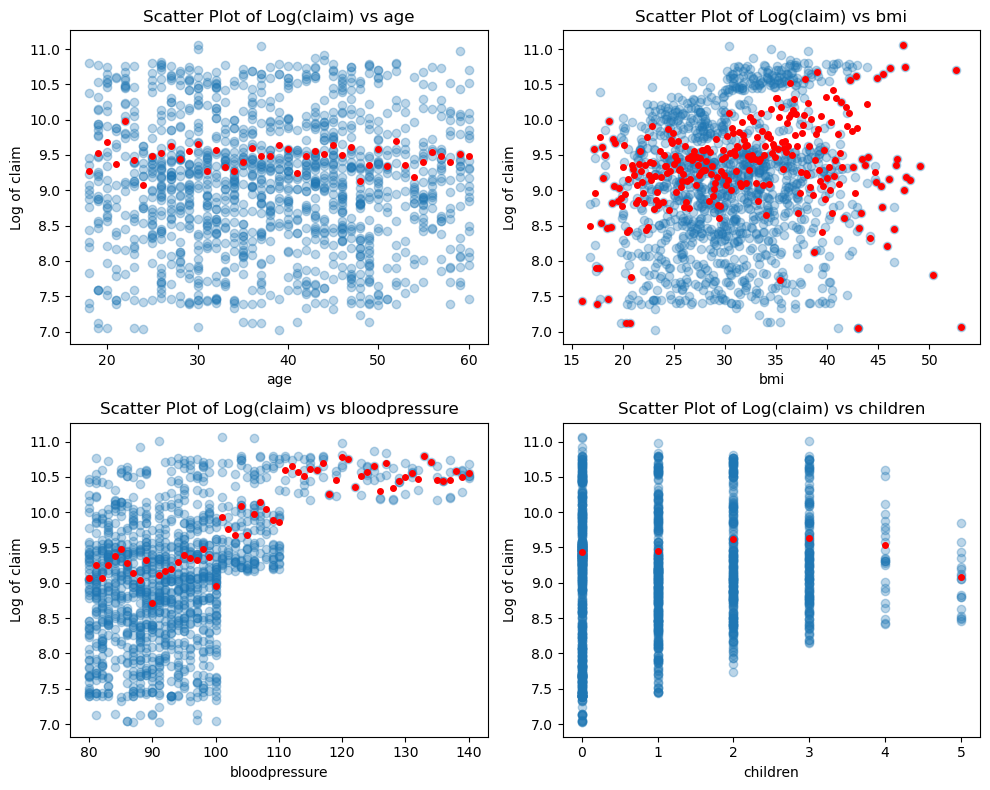

In [11]:
fig, axes = plt.subplots(2,2, figsize=(10,8))

axes = axes.flatten()

for i, col in enumerate(numerical_cols_small):
    scatter_with_avg_log(df, col, 'claim', axes[i])

plt.tight_layout()
plt.show()

Scatter plots with conditional means $E[Y|X]$ reveal that not all covariates are equally informative for predicting claim severity. While some variables exhibit clear trends, others fail to provide meaningful predictive power due to weak signal, high variability, or structural limitations. 

**Age**
Although age is often considered an important demographic factor, the conditional mean of claim severity remains relatively flat across age groups, with substantial variability at all levels. The lack of a clear monotonic or nonlinear trend suggests that age does not strongly influence severity on its own. 

**Children**
The number of children is discrete variable with limited levels, and the conditional mean of claim severity appears largely constant across categories. There is no clear evidence of increasing or decreasing severity with additional dependents.

**Blood Pressure**
Bload pressure shows a mild upward trend in average claim severity; however, the relationship is highly noisy, with significant dispersion and clustering of values. While blood pressure may have some predictive value, its effect is less reliable and may require transformation or interaction terms to be effectively incorporated into the model.

**BMI**
BMI exhibits a strong positive relationship with claim severity, with increasing variability as BMI increases. This supports the use of a Gamma GLM with a log link. 

In [12]:
df["log_claim"] = np.log(df['claim'])

df.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,log_claim
0,0,1,39,male,23.2,91,Yes,0,No,southeast,1121.87,7.022752
1,1,2,24,male,30.1,87,No,0,No,southeast,1131.51,7.031308
2,7,8,19,male,41.1,100,No,0,No,northwest,1146.80,7.044731
3,8,9,20,male,43.0,86,No,0,No,northwest,1149.40,7.046995
4,9,10,30,male,53.1,97,No,0,No,northwest,1163.46,7.059154


### Statistical Testing of Numerical Risk Factors

To assess the relationship between numerical covariates and claim severity, correlation-based and regression-based methods can also be employed. Due to the skewness and heteroskedasticity observed in the reponse variable, Spearman rank correlation is used as a non-parametric measure of association. Additionally, simple linear regression is applied to the log-transformed response variable to evaluate the significance of predictors under a linear modeling framework. 
Two test are conducted because Spearman rank correlation test can detect a simple monotonic association, while Wald test can detect how much the variable affect the response variable. 

Spearman Rank Correlation Test:
\begin{align*}
H_0&: \text{No monotonic association} \\
H_1&: \text{Monotonic association}
\end{align*}

Wald Test:
\begin{align*}
H_0&:  \beta_i = 0\\
H_1&: \beta_i \neq 0
\end{align*}


In [13]:
from scipy.stats import spearmanr

spearman_print_col = {}


for col in numerical_cols_small:
    stat, p = spearmanr(df[col], df['claim'])
    print(f'Spearman correlation between {col} and claim: {stat}, p-value: {p}')

Spearman correlation between age and claim: -0.010262563539587757, p-value: 0.7082505894224773
Spearman correlation between bmi and claim: 0.12391878298934786, p-value: 5.736980131927324e-06
Spearman correlation between bloodpressure and claim: 0.3720999384002681, p-value: 5.320926090737851e-45
Spearman correlation between children and claim: 0.12645755953878646, p-value: 3.6649422937404824e-06


In [14]:
import statsmodels.api as sm

for col in numerical_cols_small:
    X = sm.add_constant(df[col])
    y = np.log(df['claim'])
    model = sm.OLS(y, X).fit()
    print(f'OLS regression for {col}: p-value = {model.pvalues[col]}, coefficient = {model.params[col]}')

OLS regression for age: p-value = 0.7641792136429897, coefficient = -0.0006744221850380596
OLS regression for bmi: p-value = 5.704664583583921e-07, coefficient = 0.020322687378953107
OLS regression for bloodpressure: p-value = 5.738283872751844e-71, coefficient = 0.03667181721380022
OLS regression for children: p-value = 1.5696457882688704e-08, coefficient = 0.11642498430877948


Overall, these findings suggest that BMI and blood pressure are important predictors for severity modeling, while age and number of children may be excluded or treated with caution. 

## Categorial Risk Factors

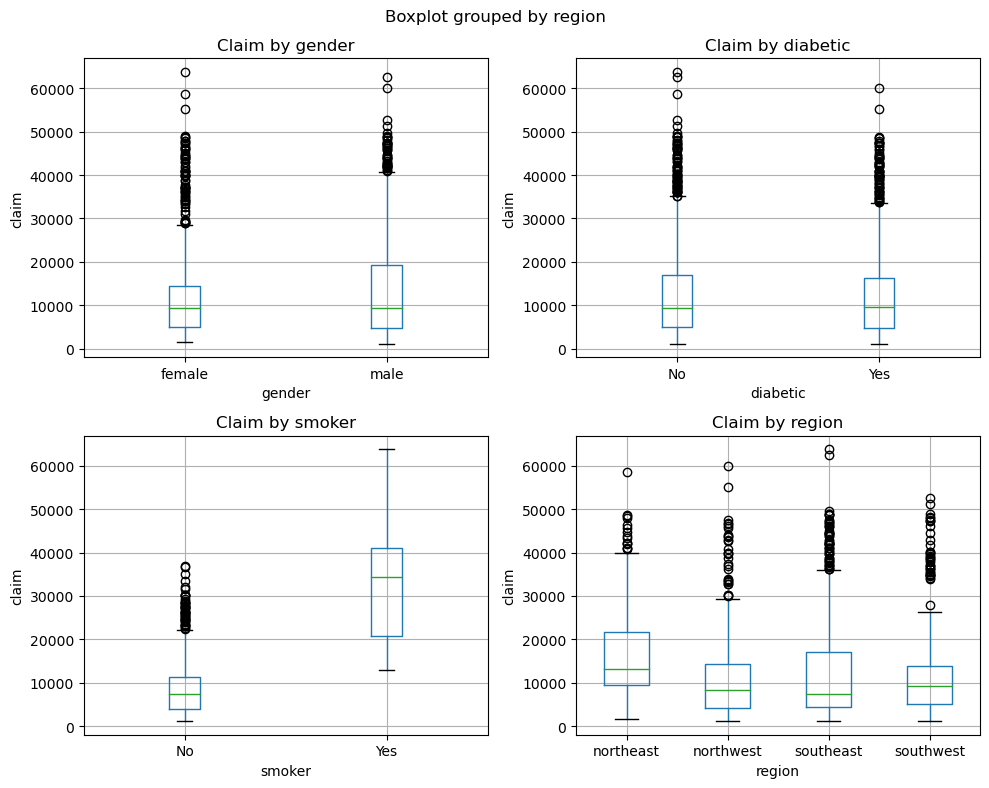

In [15]:
fig, axes = plt.subplots(2,2, figsize=(10,8))

axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df.boxplot(column='claim', by=col, ax=axes[i])
    axes[i].set_title(f'Claim by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('claim')

plt.tight_layout()
plt.show()

In [16]:
group_list = []
for col in categorical_cols:
    group_list.append(pd.DataFrame(df.groupby(col)['claim'].agg(['mean', 'median', 'count'])))

display_side_by_side(*group_list)

,mean,median,count
gender,,,
female,12569.578897,9412.965,662
male,14071.891060,9439.495,670
,mean,median,count
diabetic,,,
No,13406.602173,9301.89,695
Yes,13236.483093,9620.33,637
,mean,median,count
smoker,,,
No,8475.864537,7364.975,1058


### Statistical Testing of Categorical Risk Factors

The objective is to determine whether differences in claim severity across different groups in each categorical risk factor are statistically significant, beyond what is observed in the visualizations. 

Claim severity is highly right-skewed with heavy tails, as observed in the univariate analysis. Additionally, the variance differs substantially across groups, violating the assumptions of normality and homoscedasticity required for parametric tests such as the t-test or ANOVA.

For 2 groups (smoker, diabetic, gender):
the Mann-Whitney U test is used to compare the distributions of claim severity between two groups. This non-parametric test does not assume normality and is appropriate for skewed data.

\begin{align*}
    H_0&: \text{The distribution of claim severity is the same for both groups} \\
    H_1&: \text{The distribution differes between the two groups}
\end{align*}

For >2 groups (region):
the Kruskal-Wallis test is employed. This test generalizes the Mann-Whitney test and evaluates whether at least one group differs significantly from the others.

\begin{align*}
    H_0&: \text{All groups have the same distribution of claim severity} \\
    H_1&: \text{At least one region differs}
\end{align*}

All tests are condducted at a significance level of $\alpha = 0.05$.

In [17]:
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal

print_dict = {}

# smoker and diabetes because they have "Yes" and "No" categories
for col in categorical_cols.copy().drop(["gender", "region"]):
    group1 = df[df[col] == 'Yes']['claim']
    group2 = df[df[col] == 'No']['claim']

    stat, p = mannwhitneyu(group1, group2)
    print_dict[col] = p

# gender because it has "male" and "female" categories
group1 = df[df['gender'] == 'male']['claim']
group2 = df[df['gender'] == 'female']['claim']

stat, p = mannwhitneyu(group1, group2)
print_dict['gender'] = p

# region because it has multiple categories, we will use Kruskal-Wallis H-test
groups = [df[df['region'] == region]['claim'] for region in df['region'].unique()]
stat, p = kruskal(*groups)
print_dict['region'] = p

print_dict

{'diabetic': 0.9489491248902884,
 'smoker': 8.878460606447686e-130,
 'gender': 0.5263324324155024,
 'region': 1.7592602991741993e-13}

The results indicate that smoking status is a highly significant predictor of claim severity, with substantial difference observed in both mean and median claim amounts. This confirms the strong separation observed in exploratory analysis. Regional differences are also statistically significant; however, the magnitude of these differences is relatively moderate, suggesting limited practical impact despite statistical significance. In constrast, gender and diabetic status show no statistically significant differences in claim severity distributions, indicating limited usefulness as predictors independently.